# Feature Engineering — Almaty PM2.5

Documents and validates all 27 features used in the forecasting model.

Contents:
1. Raw feature overview
2. Lag features and autocorrelation
3. Rolling statistics
4. Cyclical time encodings
5. Meteorological derived features (BLH, wind, temp gradient)
6. Heating season indicator
7. Feature correlation matrix

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.pipeline import build_feature_matrix

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = build_feature_matrix()
print(f'{len(df):,} rows | {df.shape[1]} columns')
print(df.dtypes)

11,553 rows | 29 columns
pm25                     float64
temperature_2m           float64
relative_humidity_2m     float64
pressure_msl             float64
wind_speed_10m           float64
wind_direction_10m       float64
boundary_layer_height    float64
precipitation            float64
cams_pm25                float64
blh_log                  float64
blh_delta                float64
wind_u                   float64
wind_v                   float64
temp_gradient            float64
pm25_lag1                float64
pm25_lag3                float64
pm25_lag6                float64
pm25_lag12               float64
pm25_lag24               float64
pm25_roll3               float64
pm25_roll6               float64
pm25_roll24              float64
hour_sin                 float64
hour_cos                 float64
dow_sin                  float64
dow_cos                  float64
doy_sin                  float64
doy_cos                  float64
is_heating_season          int64
dtype: object


## 1. Raw feature overview

In [2]:
desc = df.describe().T
desc['missing%'] = df.isna().mean() * 100
print(desc[['mean','std','min','max','missing%']].round(3).to_string())

                           mean      std       min       max  missing%
pm25                     31.073   29.775     0.000   218.000       0.0
temperature_2m            7.898   11.876   -20.300    38.200       0.0
relative_humidity_2m     62.670   21.235    11.000   100.000       0.0
pressure_msl           1020.673    9.662   997.300  1058.600       0.0
wind_speed_10m            4.346    2.914     0.000    24.700       0.0
wind_direction_10m      179.270  106.360     1.000   360.000       0.0
boundary_layer_height   259.726  484.405    10.000  3935.000       0.0
precipitation             0.052    0.280     0.000     7.400       0.0
cams_pm25                24.920   13.514     1.800   110.600       0.0
blh_log                   4.355    1.517     2.303     8.278       0.0
blh_delta                -0.081  234.192 -3465.000  2590.000       0.0
wind_u                   -0.074    3.041   -13.270    20.885       0.0
wind_v                   -0.307    4.248   -19.829    21.946       0.0
temp_g

## 2. Lag features and autocorrelation

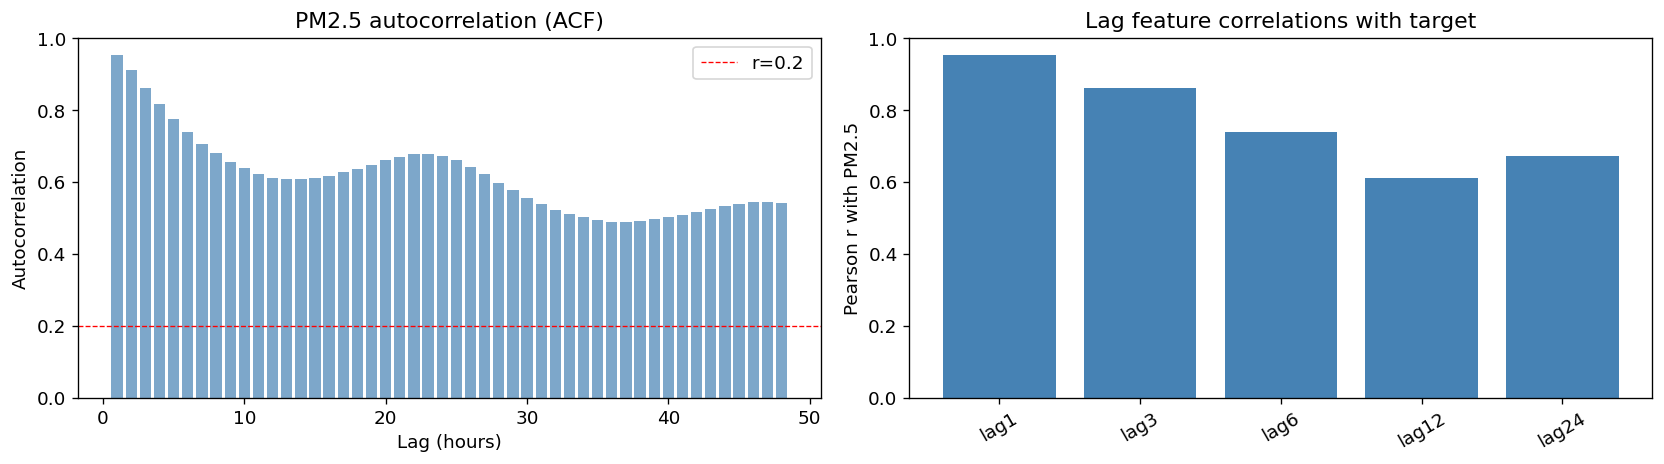

Lag correlations with PM2.5 (current hour):
  pm25_lag1: r = 0.954
  pm25_lag3: r = 0.862
  pm25_lag6: r = 0.739
  pm25_lag24: r = 0.673
  pm25_lag12: r = 0.612


In [3]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF up to 48 h
lags = range(1, 49)
acf = [df['pm25'].autocorr(lag=l) for l in lags]
axes[0].bar(lags, acf, color='steelblue', alpha=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axhline(0.2, color='red', ls='--', lw=0.8, label='r=0.2')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('PM2.5 autocorrelation (ACF)')
axes[0].legend()

# Scatter: pm25 vs pm25_lag1
lag_cols = [c for c in df.columns if c.startswith('pm25_lag')]
correlations = {c: df['pm25'].corr(df[c]) for c in lag_cols}
axes[1].bar(range(len(correlations)), list(correlations.values()), color='steelblue')
axes[1].set_xticks(range(len(correlations)))
axes[1].set_xticklabels([c.replace('pm25_','') for c in correlations], rotation=30)
axes[1].set_ylabel('Pearson r with PM2.5')
axes[1].set_title('Lag feature correlations with target')

plt.tight_layout()
plt.show()

print('Lag correlations with PM2.5 (current hour):')
for lag, r in sorted(correlations.items(), key=lambda x: -abs(x[1])):
    print(f'  {lag}: r = {r:.3f}')

## 3. BLH features — key inversion indicators

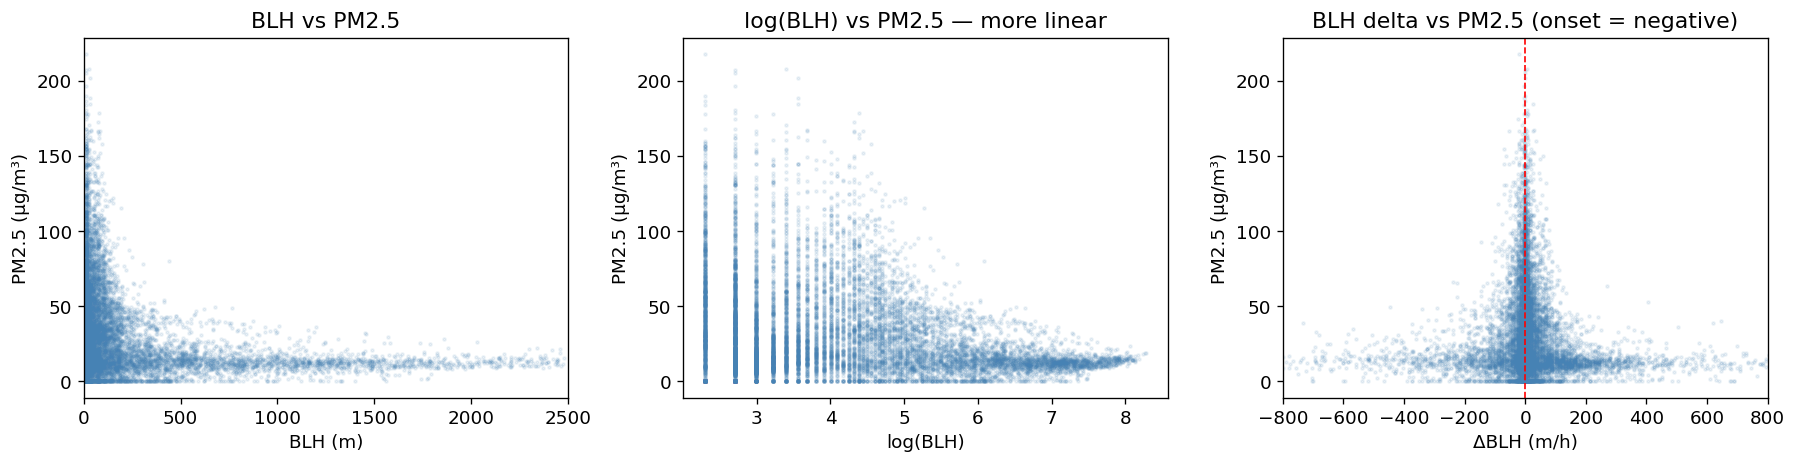

BLH (raw) vs PM2.5: r = -0.252
BLH (log) vs PM2.5: r = -0.311  ← log transform improves linearity


In [4]:
if 'boundary_layer_height' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(df['boundary_layer_height'], df['pm25'],
                    alpha=0.1, s=3, color='steelblue')
    axes[0].set_xlabel('BLH (m)')
    axes[0].set_ylabel('PM2.5 (μg/m³)')
    axes[0].set_title('BLH vs PM2.5')
    axes[0].set_xlim(0, 2500)

    axes[1].scatter(df['blh_log'], df['pm25'],
                    alpha=0.1, s=3, color='steelblue')
    axes[1].set_xlabel('log(BLH)')
    axes[1].set_ylabel('PM2.5 (μg/m³)')
    axes[1].set_title('log(BLH) vs PM2.5 — more linear')

    axes[2].scatter(df['blh_delta'], df['pm25'],
                    alpha=0.1, s=3, color='steelblue')
    axes[2].axvline(0, color='red', lw=1, ls='--')
    axes[2].set_xlabel('ΔBLH (m/h)')
    axes[2].set_ylabel('PM2.5 (μg/m³)')
    axes[2].set_title('BLH delta vs PM2.5 (onset = negative)')
    axes[2].set_xlim(-800, 800)

    plt.tight_layout()
    plt.show()

    r_raw = df[['boundary_layer_height','pm25']].corr().iloc[0,1]
    r_log = df[['blh_log','pm25']].corr().iloc[0,1]
    print(f'BLH (raw) vs PM2.5: r = {r_raw:.3f}')
    print(f'BLH (log) vs PM2.5: r = {r_log:.3f}  ← log transform improves linearity')

## 4. Cyclical encodings and heating season

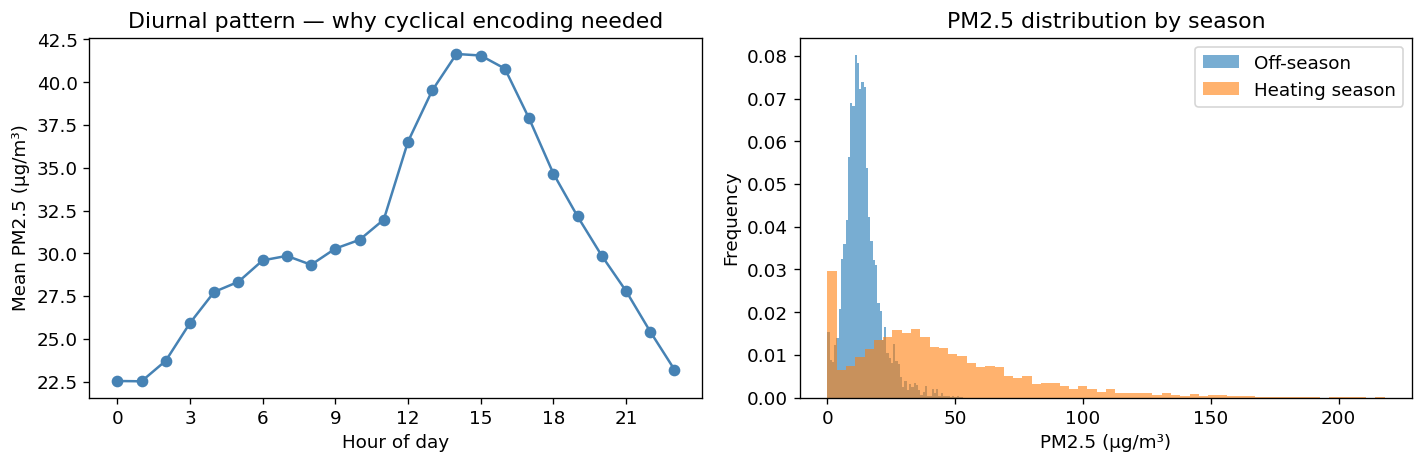

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hour of day pattern
ax = axes[0]
hours = df.groupby(df.index.hour)['pm25'].mean()
ax.plot(hours.index, hours.values, 'o-', color='steelblue')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean PM2.5 (μg/m³)')
ax.set_title('Diurnal pattern — why cyclical encoding needed')
ax.set_xticks(range(0,24,3))

# Heating season split
ax = axes[1]
if 'is_heating_season' in df.columns:
    df.groupby('is_heating_season')['pm25'].plot.hist(bins=60, alpha=0.6,
        density=True, ax=ax, label=['Off-season','Heating season'])
    ax.set_xlabel('PM2.5 (μg/m³)')
    ax.set_title('PM2.5 distribution by season')
    ax.legend(['Off-season','Heating season'])

plt.tight_layout()
plt.show()

## 5. Feature correlation matrix

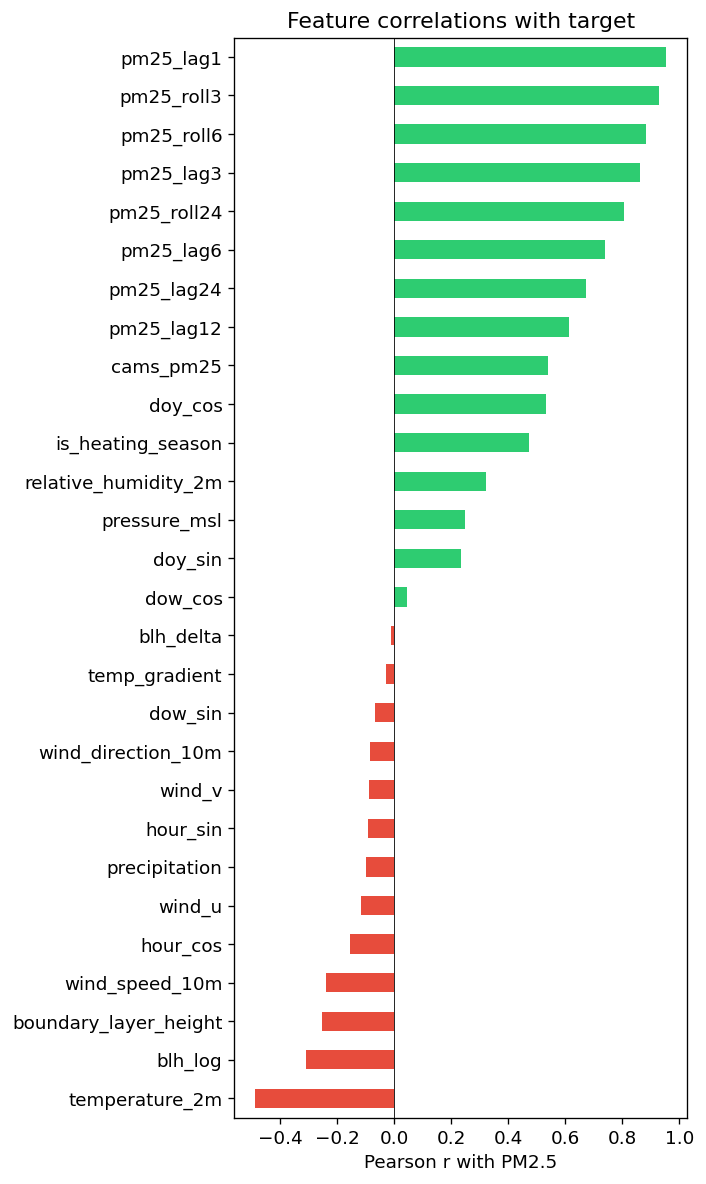

Top 5 positive correlates: {'pm25_lag1': 0.954, 'pm25_roll3': 0.928, 'pm25_roll6': 0.883, 'pm25_lag3': 0.862, 'pm25_roll24': 0.805}
Top 5 negative correlates: {'temperature_2m': -0.49, 'blh_log': -0.311, 'boundary_layer_height': -0.252, 'wind_speed_10m': -0.239, 'hour_cos': -0.157}


In [6]:
# Correlation of all features with target (pm25)
target_corr = df.corr()['pm25'].drop('pm25').sort_values()

fig, ax = plt.subplots(figsize=(6, 10))
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Pearson r with PM2.5')
ax.set_title('Feature correlations with target')
plt.tight_layout()
plt.show()

print('Top 5 positive correlates:', target_corr.nlargest(5).round(3).to_dict())
print('Top 5 negative correlates:', target_corr.nsmallest(5).round(3).to_dict())